# Data preparation audit — feature table for the low-review problem

One row per order. All logic lives in `src/` (`clf_data`, `clf_features`); this notebook builds the table,
records the split, and runs the leakage audits. Geography (audited zip-prefix coordinates, maximum route
distance) and the seed are imported from the regression package in `Phase 2/Regression/historical_temporal/src`.

Split (`config.SPLIT_SCHEME = "stratified"`): the design of Zaghloul, Barakat & Rezk (2024, *J. Retailing and
Consumer Services* 79:103865), who model the same Olist target, with a validation set added — one stratified
67/33 train+validation / test split on `is_low_review`, then a stratified 80/20 train / validation split of
the 67% (seed 5006). The assignment is written to `data/split_manifest.csv`. Because the split is random in
time, every *outcome* that feeds a history feature (seller / route delivery and review history) is taken
from **training rows only**, so no validation or test label can reach a training feature; the audit below
checks that by recomputation.

What it does
1. joins the nine raw CSVs to one order-level table (`clf_data`)
2. derives targets, assigns the split, builds every feature group — including the five engineered features
   of Zaghloul et al. in prediction-point-safe form — and the point-in-time seller / route history (`clf_features`)
3. runs the leakage assertions and writes `data/orders_features.parquet`
4. prints the split summary (report Table 3) and draws report Figure 1

Raw CSVs are found via `OLIST_CSV_DIR`, then the repo's `notebooks/data/` or `data/Olist_CSV/`, else `OLIST_ARCHIVE`.

In [1]:
from pathlib import Path
import sys, warnings
_c = Path.cwd()
ROOT = next((p for parent in [_c, *_c.parents]
             for p in (parent, parent / "Classification", parent / "Phase 2" / "Classification")
             if (p / "config" / "problem_spec.json").is_file() and (p / "src" / "paths.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the repository root, Phase 2, or Phase 2/Classification.")
sys.path.insert(0, str(ROOT / "src"))
import paths  # adds Phase 2/Regression/historical_temporal/src (regression package) to sys.path as well
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import clf_config as config, clf_features as features, clf_split as split, clf_pipelines as pipelines, clf_evaluate as evaluate
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
ACCENT, GREY, RED = "#2563eb", "#9ca3af", "#dc2626"
for d in (config.FIGURES_DIR, config.RESULTS_DIR, config.PROCESSED_DIR, config.MODELS_DIR): d.mkdir(parents=True, exist_ok=True)
print("package root:", ROOT)

package root: c:\Users\wanglr\Downloads\scp5006\IT5006-Group9-Olist-Project\Phase 2\classification


## 1. Build

In [2]:
df = features.build_feature_table(save=True)
print(df.shape, "orders x columns ->", config.FEATURE_TABLE)
print("all orders by chronological window (reference only):", df.window.value_counts().to_dict())
print("split scheme:", config.SPLIT_SCHEME, "| manifest:", config.SPLIT_MANIFEST)
df.split.value_counts()

(99421, 78) orders x columns -> C:\Users\wanglr\Downloads\scp5006\IT5006-Group9-Olist-Project\Phase 2\classification\data\orders_features.parquet
all orders by chronological window (reference only): {'train': 59427, 'maturation_gap': 19979, 'test': 12804, 'validation': 7211}
split scheme: stratified | manifest: C:\Users\wanglr\Downloads\scp5006\IT5006-Group9-Olist-Project\Phase 2\classification\data\split_manifest.csv


split
train         52482
test          32313
validation    13121
excluded       1505
Name: count, dtype: int64

## 2. Cohort and split (report Table 3)

The cohort is every reviewed order with at least one line item, delivered or not, purchased 2016-09 to 2018-08.
Rows: **train** ≈ 54% · **validation** ≈ 13% · **test** ≈ 33%, all with the same positive rate by construction.
Roles, fixed before fitting: train — fit pipelines and 5-fold stratified CV for hyperparameters; validation —
baselines vs ladder comparison, CatBoost early stopping, F1 threshold, stacking retention rule; test — scored
once per final model.

The chronological windows of the regression package are kept in `purchase_month` / `window` for the drift
figure and the robustness check in `docs/current_progress.md`; they are not used for modelling here.

In [3]:
p2 = features.cohort(df, "p2")
print("P2 rows:", len(p2))
display(split.window_summary(p2, "p2"))
# stratified 5-fold CV on the training rows (used for every hyperparameter search and the OOF probabilities)
display(split.fold_summary(split.split_frame(p2)["train"], "p2"))
# the split is uniform over time: share of each split by purchase month
pd.crosstab(p2.purchase_month, p2.split, normalize="index").round(3).T

P2 rows: 97916


,orders,first purchase,last purchase,positives,positive rate,delivered by T share
window,,,,,,
train,52482,2016-09-05,2018-08-29,7436,0.1417,0.899
validation,13121,2016-10-03,2018-08-29,1859,0.1417,0.897
test,32313,2016-09-04,2018-08-29,4579,0.1417,0.904


,fit_rows,score_rows,fit_pos_rate,score_pos_rate
fold,,,,
1,41985,10497,0.1417,0.1418
2,41985,10497,0.1417,0.1417
3,41986,10496,0.1417,0.1417
4,41986,10496,0.1417,0.1417
5,41986,10496,0.1417,0.1417


purchase_month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,2017-08,2017-09,2017-10,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
split,,,,,,,,,,,,,,,,,,,,,,,
test,0.333,0.337,1.0,0.339,0.334,0.328,0.326,0.346,0.320,0.336,0.340,0.330,0.335,0.331,0.327,0.329,0.333,0.327,0.331,0.326,0.323,0.333,0.321
train,0.667,0.518,0.0,0.546,0.544,0.543,0.541,0.520,0.544,0.530,0.521,0.546,0.533,0.533,0.545,0.530,0.536,0.538,0.529,0.538,0.544,0.531,0.545
validation,0.000,0.145,0.0,0.116,0.123,0.129,0.133,0.134,0.136,0.134,0.138,0.124,0.132,0.136,0.128,0.141,0.130,0.135,0.140,0.136,0.134,0.135,0.134


### Drift and right-censoring checks

The late-delivery rate and the review positive rate move month to month (Phase 1 Figure 2b): March 2018
is the worst month in the data (21% late, 23% low reviews) and July-August 2018 the calmest. A random split
mixes these months into every partition, so the metrics below estimate performance on the 2016-18 order mix,
not on a future month; the chronological robustness check in `docs/current_progress.md` quantifies that gap.
The last weeks of the extract are right-censored: an order only enters the delivered cohort if it arrived
before the extract date. Both facts go in report Section 2.3.

In [4]:
m = (df[df.seller_id.notna()].groupby("purchase_month")
       .agg(orders=("order_id", "size"),
            late_rate=("is_on_time", lambda s: 1 - s.mean()),
            low_review_rate=("is_low_review", "mean"),
            delivered_share=("order_delivered_customer_date", lambda s: s.notna().mean()),
            median_delivery_days=("delivery_days", "median")).round(3))
m["window"] = [features.assign_windows(pd.DataFrame({"purchase_month": [k]})).window[0] for k in m.index]
m

,orders,late_rate,low_review_rate,delivered_share,median_delivery_days,window
purchase_month,,,,,,
2016-09,3,1.000,1.000,0.333,54.813,train
2016-10,308,0.011,0.254,0.877,17.921,train
2016-12,1,0.000,0.000,1.000,4.693,train
2017-01,789,0.031,0.150,0.951,10.734,train
2017-02,1733,0.032,0.143,0.954,10.971,train
2017-03,2641,0.056,0.133,0.964,10.126,train
2017-04,2391,0.079,0.152,0.963,12.749,train
2017-05,3660,0.036,0.121,0.969,9.793,train
2017-06,3217,0.039,0.121,0.975,10.805,train


### Late delivery vs low review

Two levels. **Order level**: the phi coefficient (Pearson correlation of two binaries) and the two-way rate
table between `is_late` (delivered after the promised date, or not delivered) and `is_low_review`, on the
P2 cohort. **Month level**: Pearson and Spearman correlation between the monthly late rate and the monthly
low-review rate from the drift table above (months with fewer than 100 orders dropped), plus an order-weighted
Pearson so that the 308-order launch month (2016-10, 25% low reviews with almost no late deliveries) does not
dominate. The first is the individual effect that the delivery-status features exploit; the second is the drift
that a random split averages away.

order level: phi = 0.427  (chi-square p = 0.0e+00); low-review rate 58.9% when late vs 9.2% when on time -> relative risk 6.4x


is_low_review,review 3-5,review 1-2,orders
row_0,,,
on time,0.908,0.092,88168
late / not delivered,0.411,0.589,9748


month level (21 months): Pearson r = 0.475 (p = 0.029), Spearman rho = 0.313 (p = 0.166), order-weighted r = 0.850


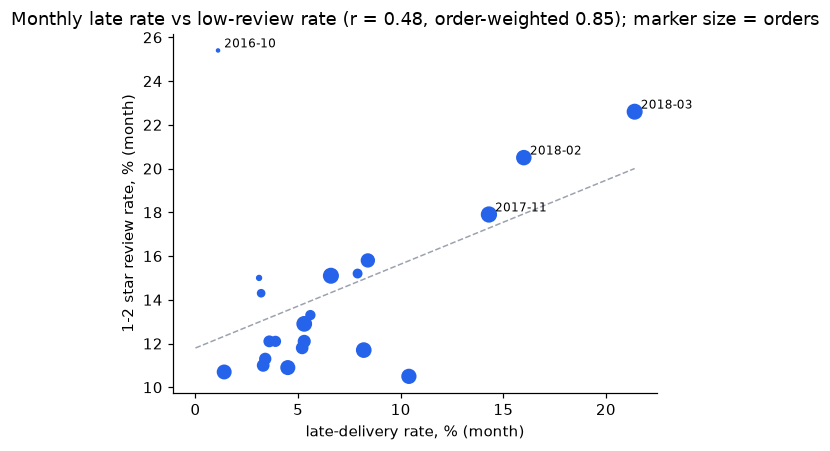

In [5]:
from scipy import stats
# order level: late = delivered after the promise, or not delivered at all
late = np.where(p2.order_delivered_customer_date.isna(), 1.0, 1 - p2.is_on_time.fillna(1.0))
low = p2.is_low_review.astype(float)
phi = np.corrcoef(late, low)[0, 1]
chi2, pval, _, _ = stats.chi2_contingency(pd.crosstab(late, low))
rate = pd.crosstab(late, low, normalize="index").rename(index={0.0: "on time", 1.0: "late / not delivered"},
                                                        columns={0.0: "review 3-5", 1.0: "review 1-2"}).round(3)
rate["orders"] = pd.Series(late).value_counts().rename({0.0: "on time", 1.0: "late / not delivered"})
print(f"order level: phi = {phi:.3f}  (chi-square p = {pval:.1e}); low-review rate {rate.iloc[1, 1]:.1%} when late vs {rate.iloc[0, 1]:.1%} when on time "
      f"-> relative risk {rate.iloc[1, 1] / rate.iloc[0, 1]:.1f}x")
display(rate)
# month level: drift table, months with >= 100 orders
mm = m[m.orders >= 100]
r_p, p_p = stats.pearsonr(mm.late_rate, mm.low_review_rate)
r_s, p_s = stats.spearmanr(mm.late_rate, mm.low_review_rate)
w = mm.orders / mm.orders.sum()   # order-weighted Pearson: 2016-10 (308 orders, launch month) otherwise dominates
cov = np.cov(mm.late_rate, mm.low_review_rate, aweights=w)
r_w = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
print(f"month level ({len(mm)} months): Pearson r = {r_p:.3f} (p = {p_p:.3f}), Spearman rho = {r_s:.3f} (p = {p_s:.3f}), order-weighted r = {r_w:.3f}")
corr = pd.DataFrame({"level": ["order (phi)", "month (Pearson)", "month (Spearman)", "month (order-weighted Pearson)"],
                     "correlation": [phi, r_p, r_s, r_w], "p_value": [pval, p_p, p_s, np.nan], "n": [len(p2), len(mm), len(mm), len(mm)]})
corr.to_csv(config.RESULTS_DIR / "late_vs_low_review_correlation.csv", index=False)
fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.scatter(mm.late_rate * 100, mm.low_review_rate * 100, color=ACCENT, s=mm.orders / 80)
for k, r in mm.iterrows():
    if r.late_rate > 0.12 or r.low_review_rate > 0.17: ax.annotate(k, (r.late_rate * 100, r.low_review_rate * 100), fontsize=8, xytext=(4, 2), textcoords="offset points")
b, a = np.polyfit(mm.late_rate * 100, mm.low_review_rate * 100, 1); xs = np.linspace(0, mm.late_rate.max() * 100, 10)
ax.plot(xs, a + b * xs, ls="--", color=GREY, lw=1)
ax.set_xlabel("late-delivery rate, % (month)"); ax.set_ylabel("1-2 star review rate, % (month)")
ax.set_title(f"Monthly late rate vs low-review rate (r = {r_p:.2f}, order-weighted {r_w:.2f}); marker size = orders")
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / "01b_late_vs_low_review.png", bbox_inches="tight")

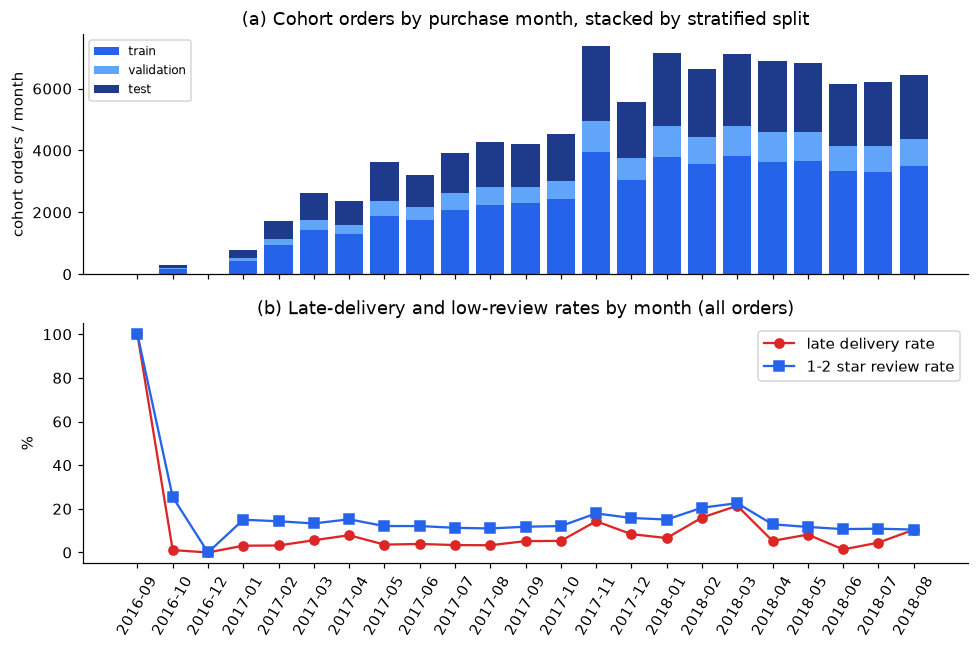

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
by_split = pd.crosstab(p2.purchase_month, p2.split).reindex(m.index).fillna(0)[["train", "validation", "test"]]
x = np.arange(len(m))
colors = {"train": ACCENT, "validation": "#60a5fa", "test": "#1e3a8a"}
bottom = np.zeros(len(m))
for name in by_split.columns:
    ax[0].bar(x, by_split[name].values, bottom=bottom, color=colors[name], label=name); bottom += by_split[name].values
ax[0].set_ylabel("cohort orders / month"); ax[0].set_title("(a) Cohort orders by purchase month, stacked by stratified split"); ax[0].legend(fontsize=8)
ax[1].plot(x, m.late_rate * 100, marker="o", color=RED, label="late delivery rate")
ax[1].plot(x, m.low_review_rate * 100, marker="s", color=ACCENT, label="1-2 star review rate")
ax[1].set_ylabel("%"); ax[1].set_title("(b) Late-delivery and low-review rates by month (all orders)"); ax[1].legend()
ax[1].set_xticks(x); ax[1].set_xticklabels(m.index, rotation=60)
plt.tight_layout(); fig.savefig(config.FIGURES_DIR / "01_windows_and_rates.png", bbox_inches="tight")

## 3. Feature catalogue, prediction-point flags and missingness

Feature names follow Zaghloul et al. (2024) where they have one (`wd_actual_delivery_time`, `wd_delivery_time_delta`,
`total_order_value`, `payment_total`, `freight_ratio`). The difference from the paper is *when* a feature is evaluated:
every delivery-status feature is computed **as of the prediction point T** = min(delivered, estimated) — identical to the
paper's value for orders delivered by T, NaN (with an indicator) for the ~10% not yet delivered when the survey goes out.
The table flags these **T-dependent** features; they must never be used for a question asked at order time
(e.g. the regression problem), and `config/feature_roles.csv` carries the same flag.

Missing values are expected and meaningful for the T-dependent block. Every pipeline imputes with an indicator inside its own fit.

In [7]:
pp = config.prediction_point_table()
print("features by prediction point:"); display(pp.groupby("prediction_point").feature.agg(["size", lambda s: ", ".join(s)]).rename(columns={"size": "n", "<lambda_0>": "features"}))
print("T-dependent features (flagged):", config.features_at_T())
assert set(config.features_at_T()) == set(pp[pp.T_dependent].feature)
assert not set(config.features_at_T()) & set(config.features_for("p1")), "T-dependent features must not enter the order-time problem"

features by prediction point:


,n,features
prediction_point,,
order approval,34,"n_items, n_distinct_products, n_sellers, total..."
"purchase time (point-in-time, training-row outcomes only)",9,"seller_prior_orders, seller_tenure_days, selle..."
"survey trigger T = min(delivered, estimated) - T-dependent",9,"is_delivered, actual_delivery_time, delivery_t..."


T-dependent features (flagged): ['is_delivered', 'actual_delivery_time', 'delivery_time_delta', 'carrier_shipped', 'carrier_handover_days', 'carrier_transit_days', 'delivery_vs_seller_prior', 'wd_actual_delivery_time', 'wd_delivery_time_delta']


In [8]:
print(f"p2: {len(config.features_for('p2'))} features")
nan = p2[config.features_for("p2")].isna().mean().round(3)
nan[nan > 0].sort_values(ascending=False).to_frame("share missing (P2 cohort)")

p2: 52 features


,share missing (P2 cohort)
actual_delivery_time,0.100
wd_actual_delivery_time,0.100
delivery_time_delta,0.100
delivery_vs_seller_prior,0.100
carrier_transit_days,0.100
wd_delivery_time_delta,0.100
carrier_handover_days,0.015
main_category,0.014
max_distance_km,0.005


In [9]:
# the T-dependent delivery block is where the Problem 2 signal lives
p2.groupby("is_delivered").is_low_review.agg(["mean", "size"]).rename(columns={"mean": "low-review rate", "size": "orders"})

,low-review rate,orders
is_delivered,,
0.0,0.589454,9748
1.0,0.092188,88168


## 4. Leakage audit

`features.assert_no_leakage` is structural (no post-outcome column can be a feature; the delivery-as-of-T block is
empty for orders not delivered by T). `features.leakage_audit` adds empirical checks: seller history recomputed
from scratch for a sample of orders — only outcomes known before purchase **and belonging to training rows** may
contribute, and the smoothed seller late rate is rebuilt from those rows and compared exactly — internal consistency
of the delivery-as-of-T block, the share of reviews written before the survey trigger T, and the ranking power of every
feature on its own (a value near 1.0 would mean a feature encodes the label; `is_delivered` leading at about 0.77
is the delivery effect Phase 1 documented, not leakage).

In [10]:
features.assert_no_leakage(p2, "p2")
print("post-outcome columns (never features):", sorted(config.POST_OUTCOME_COLUMNS))
audit = features.leakage_audit(p2, "p2", sample=3000, full=df)
for k in ("history", "at_T", "review_time"):
    print(f"--- {k}"); print(audit[k].round(4).to_string())
audit["single_feature_auc"].to_csv(config.RESULTS_DIR / "single_feature_auc.csv", index=False)
display(audit["single_feature_auc"].head(12).round(3))
assert audit["history"]["only outcomes known before purchase"] == 1.0
assert audit["history"]["late rate rebuilt from training-row outcomes only"] == 1.0
assert audit["single_feature_auc"].roc_auc.max() < 0.9, "a single feature ranks the label almost perfectly: inspect it"
split.window_summary(p2, "p2").to_csv(config.RESULTS_DIR / "split_summary.csv")
split.fold_summary(split.split_frame(p2)["train"], "p2").to_csv(config.RESULTS_DIR / "fold_summary.csv")
import json
json.dump({"orders": int(len(df)), "p2_cohort": int(len(p2)), "windows": split.window_summary(p2, "p2").orders.to_dict(),
           "split_scheme": config.SPLIT_SCHEME, "test_size": config.TEST_SIZE, "validation_size": config.VALIDATION_SIZE,
           "features": len(config.features_for("p2")), "leakage_audit_passed": True,
           "reviews_before_T_share": float(audit["review_time"]["reviews created before T"])},
          open(config.ROOT / "outputs" / "data_quality.json", "w"), indent=2)
print("OK - leakage audit passed")

post-outcome columns (never features): ['delivery_days', 'has_review_comment', 'is_low_review', 'is_on_time', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_status', 'review_answer_timestamp', 'review_creation_date', 'review_score', 'survey_trigger_time']
--- history
orders checked                                       3000.0
seller_prior_orders exact match                         1.0
only outcomes known before purchase                     1.0
late rate rebuilt from training-row outcomes only       1.0
--- at_T
actual_delivery_time is NaN when not delivered by T    1.0000
delivery_time_delta <= 0 when delivered by T           1.0000
carrier_handover only when carrier date <= T           1.0000
is_delivered share                                     0.9004
--- review_time
reviews created before T        0.0311
median days from T to review    0.2732


,feature,roc_auc,pr_auc
0,is_delivered,0.690,0.334
1,seller_id_enc,0.609,0.206
2,customer_zip2,0.598,0.196
3,total_freight,0.578,0.179
4,carrier_handover_days,0.572,0.190
5,customer_state,0.570,0.176
6,route_prior_mean_delivery_days,0.565,0.175
7,main_category,0.563,0.172
8,seller_prior_low_review_rate,0.555,0.180
9,n_items,0.555,0.168


OK - leakage audit passed
